#### Question Statement

## Q.2 Building Markov transition matrix
You have learned important differences between simple dinucleotide frequency model and Markov models. Your goal is to build one from the input sequence. In the Jupyter notebook, you should print the transition matrix.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:

# our DNA string
dna_sequence = "GTTCTACTTGCGACGTTAGGACGGATCGTAACCGAACTGGCCCGGATCTTTCATCCTCATGTAGATGCACAAAAGGTTCATCTAATAGTACTACCTCTTCTACTCGC"
sequence_length = len(dna_sequence)

# the four valid bases
bases = ['A', 'C', 'G', 'T']

# we'll keep track of any other characters we stumble upon
invalid_pairs = []

# initialize a nested mapping: base → (next_base → count)
pair_counts = {
    base: {next_base: 0 for next_base in bases}
    for base in bases
}

# walk through each adjacent pair in our sequence
for i in range(sequence_length - 1):
    current = dna_sequence[i]
    following = dna_sequence[i + 1]

    # make sure we only count real bases
    if current not in bases or following not in bases:
        invalid_pairs.append((current, following))
    else:
        pair_counts[current][following] += 1

# if anything weird showed up
if invalid_pairs:
    for bad in invalid_pairs:
        print(f"Unexpected characters encountered {bad}")

# now convert raw counts into probabilities
transition_probs = {}
for base in bases:
    counts = pair_counts[base]
    total_for_base = sum(counts.values())
    transition_probs[base] = {}
    for next_base in bases:
        if total_for_base > 0:
            transition_probs[base][next_base] = counts[next_base] / total_for_base
        else:
            # no transitions from this base, so set to zero
            transition_probs[base][next_base] = 0.0

# build a pandas DataFrame for nice display
df = pd.DataFrame.from_dict(transition_probs, orient='index')

print("\nTransition Probability Matrix:")
print(df)


Transition Probability Matrix:
          A         C         G         T
A  0.230769  0.346154  0.153846  0.269231
C  0.178571  0.178571  0.250000  0.392857
G  0.285714  0.190476  0.238095  0.285714
T  0.290323  0.354839  0.129032  0.225806


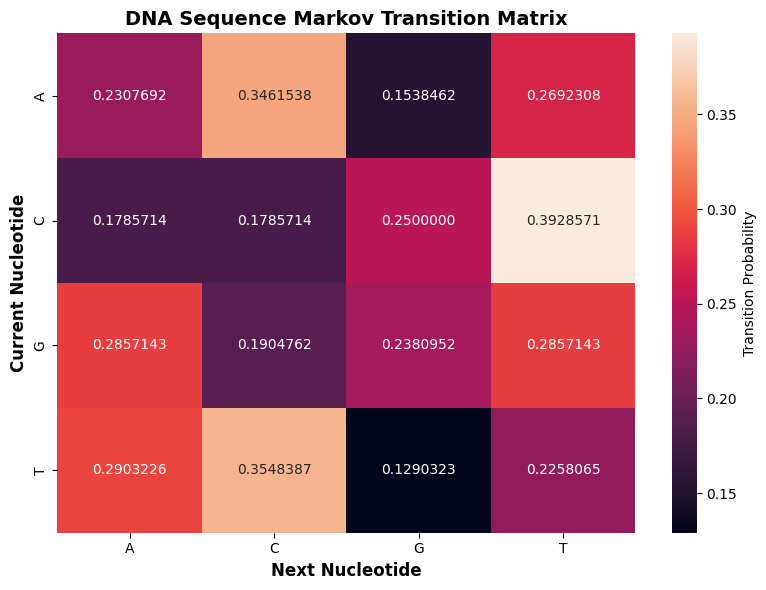

In [8]:
plt.figure(figsize=(8, 6))
vibrant_cmap = sns.color_palette("rocket", as_cmap=True)

sns.heatmap(
    df,
    annot=True,
    fmt=".7f",
    cmap=vibrant_cmap,
    cbar_kws={"label": "Transition Probability"}
)

plt.xlabel("Next Nucleotide", fontsize=12, fontweight="bold")
plt.ylabel("Current Nucleotide", fontsize=12, fontweight="bold")
plt.title("DNA Sequence Markov Transition Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
num_transitions = sequence_length - 1
# build a flat mapping
pair_frequencies_dict = {
    f"{base1}{base2}": pair_counts[base1][base2] / num_transitions
    for base1 in bases
    for base2 in bases
}

# sorting the pairs alphabetically for plotting
sorted_pair_keys = sorted(pair_frequencies_dict.keys())
sorted_pair_values = [pair_frequencies_dict[p] for p in sorted_pair_keys]

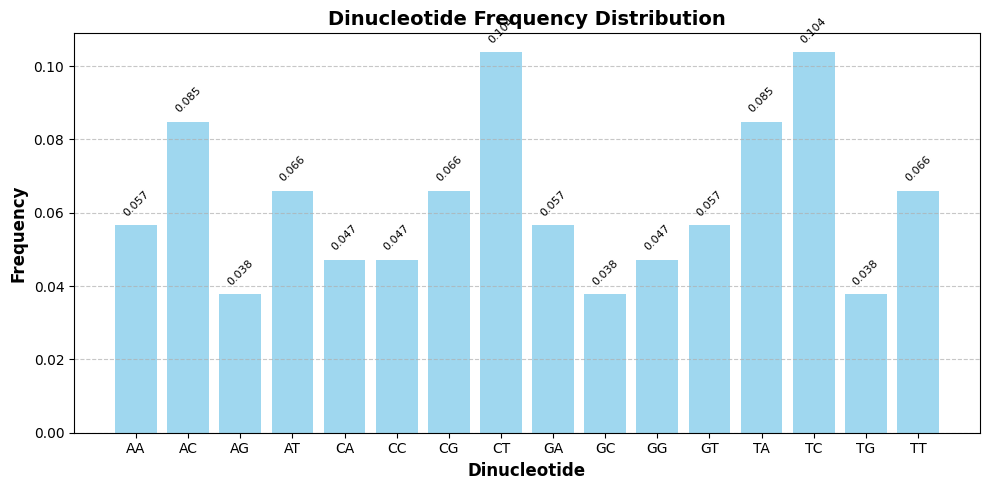

In [10]:
plt.figure(figsize=(10, 5))
bars = plt.bar(sorted_pair_keys, sorted_pair_values, color='skyblue', alpha=0.8)

plt.xlabel('Dinucleotide', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Dinucleotide Frequency Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# add numbers above each bar so you can see the exact frequencies
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        rotation=45,
        fontsize=8
    )

plt.tight_layout()
plt.show()

## How to Read the Transition Matrix

This table tells you how likely it is to go from one DNA base (on the left) to another base (across the top).

Take the entry in row “A” and column “C”: that number is P(C | A), or “the chance of seeing a C right after an A.”

Likewise, the entry in row “G” and column “T” is P(T | G) — the probability of a T following a G.

## Dinucleotide Counts vs. First‑Order Markov

Dinucleotide Counts
You simply tally every pair of neighboring bases (AA, AC, AG, etc.), then divide by the total number of pairs to get frequencies. This gives you a snapshot of which two‑letter combinations occur most often overall.

First‑Order Markov Model
Instead of looking at joint occurrences, this model asks: “Given that I’m currently at base X, what’s the probability I’ll move to base Y next?” In other words, it captures the dependency of each step on the one immediately before it.

Conclusion
A simple dinucleotide frequency tells you how common each pair is in your sequence as a whole, while a first‑order Markov model breaks that down into conditional probabilities, showing how each base influences the next.